# Tests with one agent only

In [37]:
# The tests are particularly interesting with Watts-Strogatz networks
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}

from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel

In [39]:
# Initial tests
all_agents_game = statusgame_model(N=50, seed=666, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=0.4, k=10, rho=1/3, seed_consumption=True, alpha=1)

one_agent_game = OneActiveStatusGameModel(N=50, one_active_agent_id=2, seed=666, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=0.4, k=10, rho=1/3, seed_consumption=True, alpha=1)

for node_id, agent in one_agent_game.agents_dict.items():
    one_agent_game.G.nodes[node_id]["group"] = agent.assigned_group
nx.write_gexf(one_agent_game.G, "initial_graph.gexf")


In [40]:
np.median([10,12,13,14])
median_value = np.median([10, 10, 10, 10, 10])
differences = np.abs(np.array([10, 10, 10, 10, 10]) - median_value)
rankings = stats.rankdata(differences, method="max")

In [41]:
rankings

array([5, 5, 5, 5, 5])

In [42]:
# Run the models
for _ in range(70):
    all_agents_game.step()
    one_agent_game.step()
for node_id, agent in one_agent_game.agents_dict.items():
    one_agent_game.G.nodes[node_id]["group"] = agent.assigned_group
nx.write_gexf(one_agent_game.G, "final_graph.gexf")
# Collect dataframes
all_agents_df = all_agents_game.datacollector.get_agent_vars_dataframe().reset_index()
one_agent_df = one_agent_game.datacollector.get_agent_vars_dataframe().reset_index()

No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered candidates
No filtered

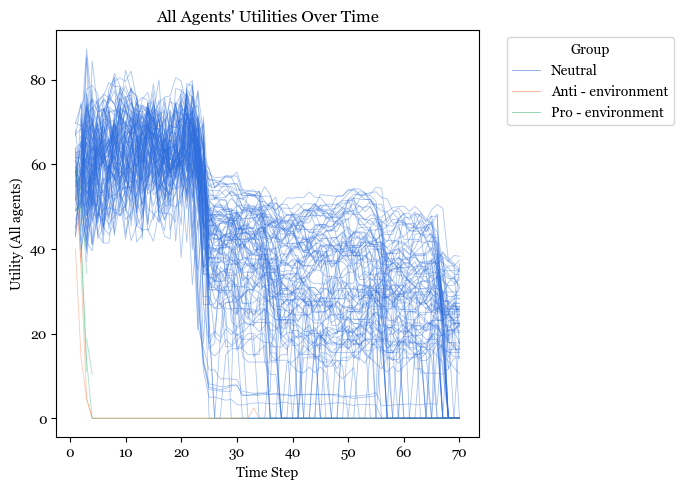

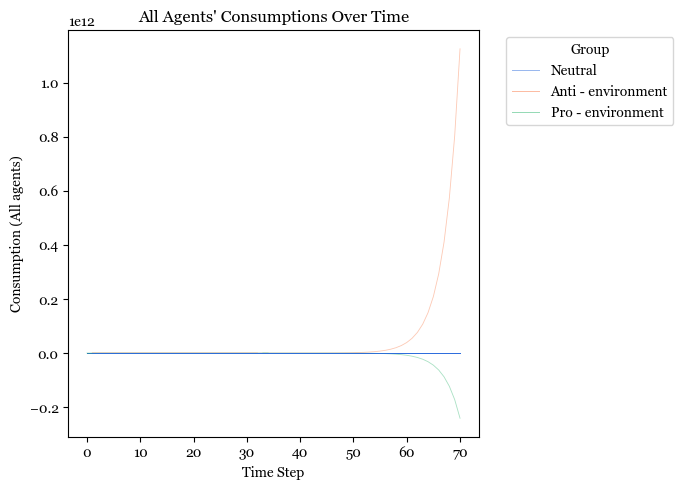

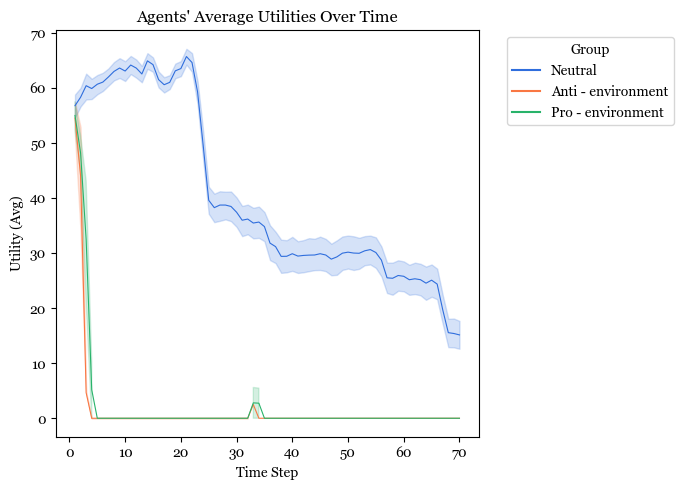

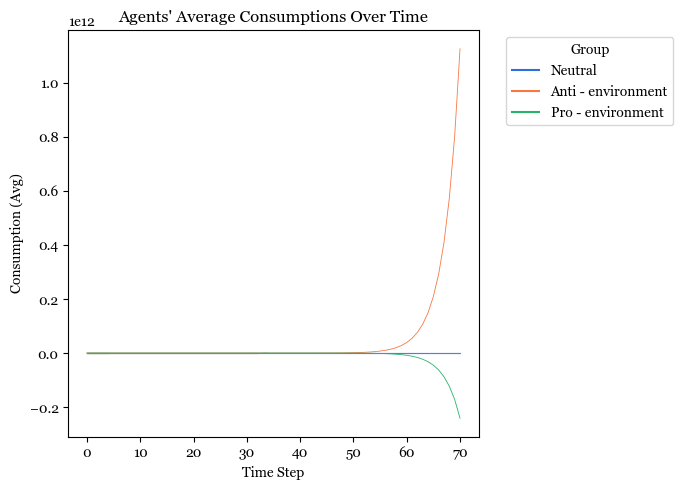

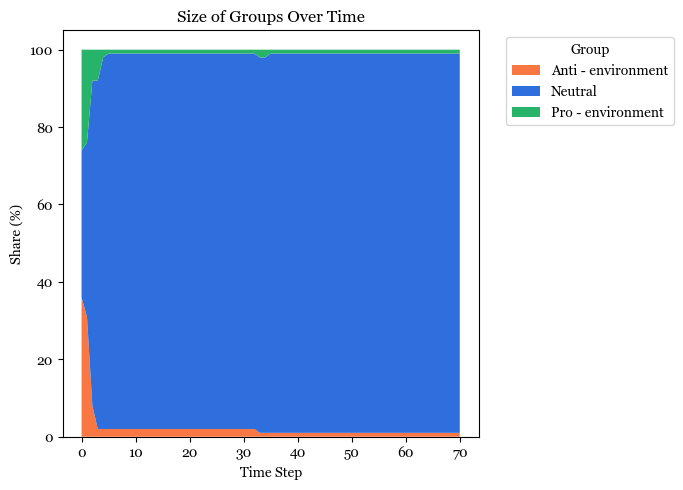

In [38]:
# Plots
plot_all_agent_graphs(all_agents_df, color_dict, output_folder="plots/all", show_plots=True)

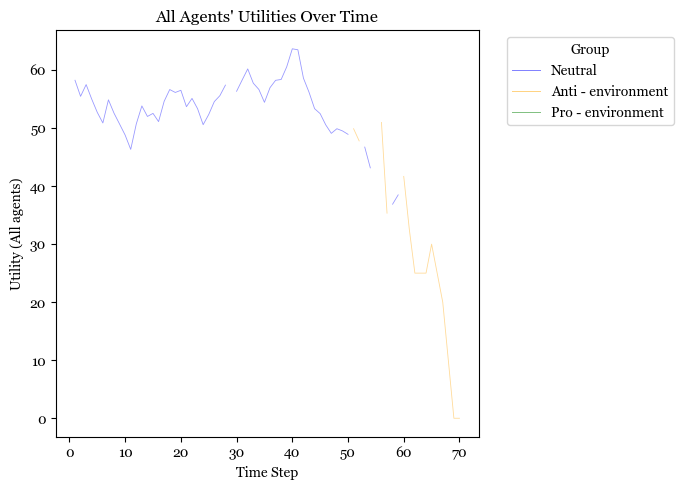

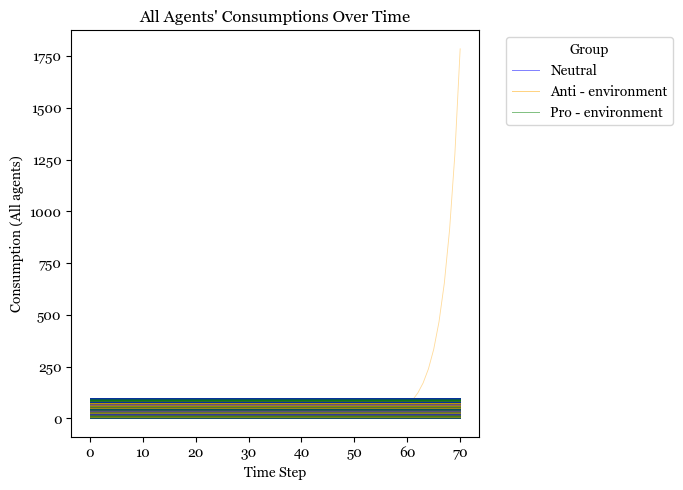

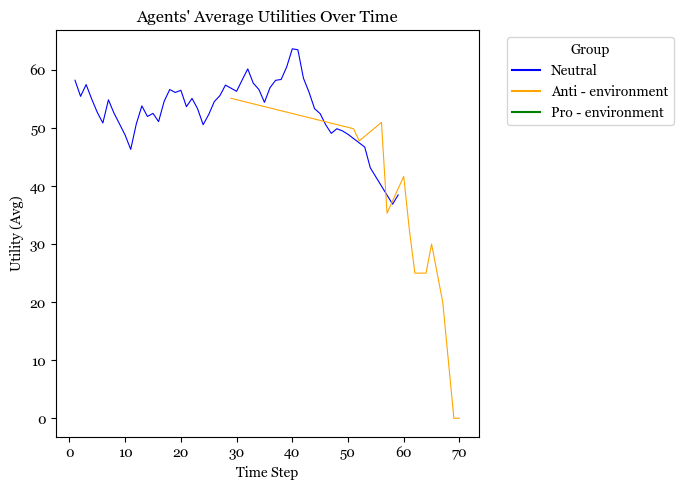

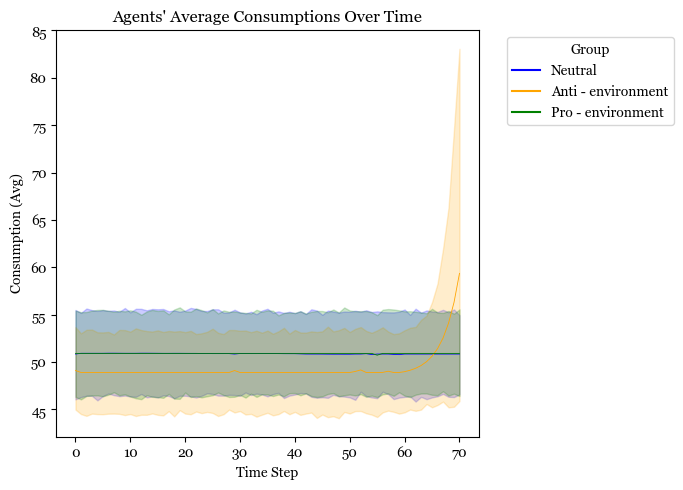

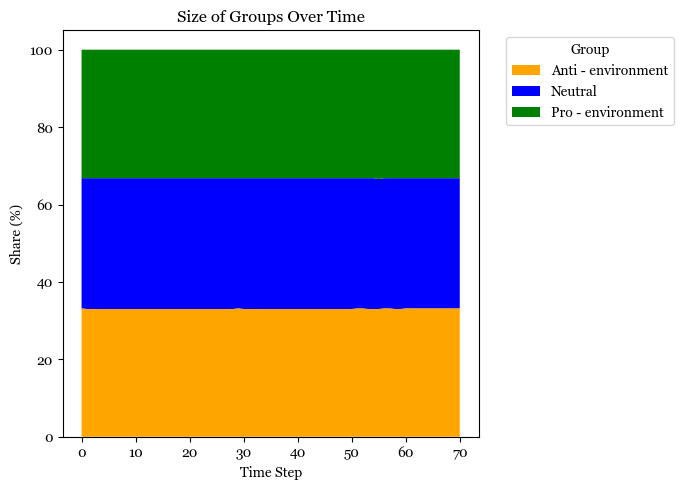

In [13]:
#Plots one agent
plot_all_agent_graphs(one_agent_df, color_dict, output_folder="plots/one", show_plots=True)

In [14]:
timeline_1 = one_agent_df.loc[one_agent_df["AgentID"] == 2]

In [5]:
listi = []
listi = [np.exp(-i) for i in listi]
w = [i / sum(listi) for i in listi]

In [10]:
if not listi:
    print("yes")

yes


In [38]:
sum(w)

1.0

In [46]:
round(3825450830873.0 / 10**12, 2)

3.83

In [8]:
# Batch run to look at avg friends in common
# Now, test on only one agent
params = {"seed": 666, 
          "alpha": np.linspace(0.001, 1, 20),
          'N':[100],
          "gamma": [0.1], 
          "create_network": "watts_strogatz", 
          "k": [20], 
          "p": [1/10],
          "rho": 1/3, 
          "one_active_agent_id": [2], 
          "seed_consumption": True, 
          "memory": [20]}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=5,
    max_steps=200,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1_one_agent.csv")

  0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
results_avg_common = results_batch_df.loc[results_batch_df["AgentID"] == 2]

<Axes: xlabel='alpha', ylabel='avg_common'>

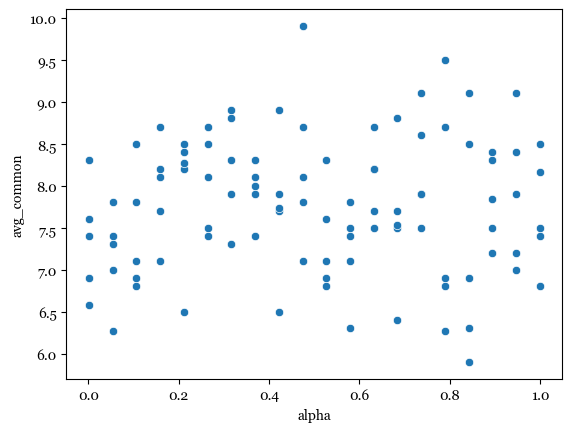

In [10]:
sns.scatterplot(data=results_avg_common, x="alpha", y="avg_common")

In [11]:
results_avg_common.alpha.value_counts().sort_index()

0.001000    5
0.053579    5
0.106158    5
0.158737    5
0.211316    5
0.263895    5
0.316474    5
0.369053    5
0.421632    5
0.474211    5
0.526789    5
0.579368    5
0.631947    5
0.684526    5
0.737105    5
0.789684    5
0.842263    5
0.894842    5
0.947421    5
1.000000    5
Name: alpha, dtype: int64

In [8]:
# Data for multiple tests / agents
# Create lists for each group
ids_anti = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Anti - environment")]["AgentID"].tolist()
ids_neutral = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Neutral")]["AgentID"].tolist()
ids_pro = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Pro - environment")]["AgentID"].tolist()

In [9]:
# First, test on all agents changing gamma 
# Change only gamma / k
params = {"seed": 666, 
          'N':[250],
          "gamma": np.linspace(0.01, 1, 10), 
          "create_network": "watts_strogatz", 
          "k": [5, 10, 20, 40, 80], 
          "p": [1/10],
          "rho": 1/3, 
          "seed_consumption": True}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=5,
    max_steps=100,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1.csv")


  0%|          | 0/250 [00:00<?, ?it/s]

Process SpawnPoolWorker-7:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-6:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-1:


KeyboardInterrupt: 

In [ ]:
# Now, test on only one agent
params = {"seed": 666, 
          'N':[250],
          "gamma": np.linspace(0.01, 1, 10), 
          "create_network": "watts_strogatz", 
          "k": [5, 10, 20, 40, 80], 
          "p": [1/10],
          "rho": 1/3, 
          "one_active_agent_id": ids_pro[0:20], 
          "seed_consumption": True}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=1,
    max_steps=100,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1_one_agent.csv")

  0%|          | 0/1000 [00:00<?, ?it/s]